<img src="http://www.cidaen.es/assets/img/mCIDaeNnb.png" alt="Logo CiDAEN" align="right">


<br><br><br><br>

<h1><font color="#00586D" size=5>Prueba del modelo desplegado en SageMaker desde entorno local</font></h1>
<br><br>


<div align="right">
<font color="#00586D" size=3>Javier de la Ossa</font><br>
<font color="#00586D" size=3>Máster en Ciencia de Datos e Ingeniería de Datos en la Nube</font><br>
<font color="#00586D" size=3>Universidad de Castilla-La Mancha</font>

</div>

In [1]:
import boto3
import base64 
import cv2
import io
import json
import numpy as np
import matplotlib.pyplot as plt

SM_ENDPOINT = "yolov8-pytorch-2024-09-07-08-39-56-003428"

---
<a id="indice"></a>
<h2><font color="#00586D" size=5>Índice</font></h2>


* [1. Carga y preprocesamiento de una imagen](#section1)
* [2. Pruebas de codificación de la imagen](#section2)
* [3. Invocación del endpoint de SageMaker](#section3)
* [4. Pruebas invocación Lambda para obtener inferencia en SageMaker](#section4)

<br>

---

<a id="section1"></a>
## <font color="#00586D"> 1. Carga y preprocesamiento de una imagen</font>
<br>

In [2]:
image_path = "../../samples/mercadona_00016.jpg"
receipt_image = cv2.imread(image_path)

image_height, image_width, _ = receipt_image.shape
model_height, model_width = 640, 320

x_ratio = image_width/model_width
y_ratio = image_height/model_height

resized_image = cv2.resize(receipt_image, (model_width, model_height))
_, encoded_image = cv2.imencode(".jpg", resized_image)
encoded_image

array([255, 216, 255, ...,   0, 255, 217], dtype=uint8)

In [3]:
def resize_and_encode(image_path: str, model_height: int  = 640, model_width: int = 320) -> tuple:
    """
    Reads an image from the specified file path, resizes it to the specified dimensions,
    and encodes it into JPEG format. Also returns the ratios of the original image 
    dimensions to the model dimensions.

    :param image_path (str): The file path to the image to be processed.
    :param model_height (int, optional): The desired height for the resized image. Defaults to 640.
    :param model_width (int, optional): The desired width for the resized image. Defaults to 320.
    :return: A tuple containing:
             - x_ratio (float): The ratio of the original image width to the model width.
             - y_ratio (float): The ratio of the original image height to the model height.
             - resized_image (np.array): The resized image as a NumPy array.
             - encoded_image (np.array): The JPEG-encoded image as a NumPy array.
    """
    image = cv2.imread(image_path)
    image_height, image_width, _ = image.shape
    x_ratio = image_width / model_width
    y_ratio = image_height / model_height

    resized_image = cv2.resize(image, (model_width, model_height))
    _, encoded_image = cv2.imencode(".jpg", resized_image)
    
    return (x_ratio, y_ratio, resized_image, encoded_image)

In [4]:
x_ratio, y_ratio, resized_image, encoded_image = resize_and_encode(image_path)

print(f"X ratio: {x_ratio}")
print(f"Y ratio: {y_ratio}")

print("Resized image:")
print(resized_image)

print("Encoded image:")
print(encoded_image)

X ratio: 5.3125
Y ratio: 5.61875
Resized image:
[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]
Encoded image:
[255 216 255 ...   0 255 217]


<a id="section2"></a>
## <font color="#00586D"> 2. Pruebas de codificación de la imagen</font>
<br>

In [5]:
base64_image = base64.b64encode(encoded_image).decode("utf-8")
base64_image[:100]

'/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAIBAQEBAQIBAQECAgICAgQDAgICAgUEBAMEBgUGBgYFBgYGBwkIBgcJBwYGCAsICQoK'

In [6]:
json_payload = json.dumps({"receipt_image": base64_image})
type(json_payload)

str

In [7]:
lambda_base64_image = json.loads(json_payload)["receipt_image"]
lambda_base64_image[:100]

'/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAIBAQEBAQIBAQECAgICAgQDAgICAgUEBAMEBgUGBgYFBgYGBwkIBgcJBwYGCAsICQoK'

In [8]:
base64_decoded_image = base64.b64decode(base64_image)
type(base64_decoded_image)

bytes

In [9]:
np_array = np.frombuffer(base64_decoded_image, np.uint8)
np_array

array([255, 216, 255, ...,   0, 255, 217], dtype=uint8)

In [10]:
(encoded_image == np_array).all()

True

In [11]:
image_io = io.BytesIO()
np.save(image_io, np_array, allow_pickle=True)
payload = image_io.getvalue()
type(payload)

bytes

<a id="section3"></a>
## <font color="#00586D"> 3. Invocación del endpoint de SageMaker</font>
<br>

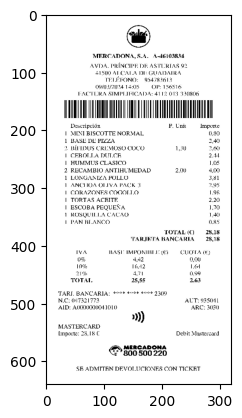

In [12]:
plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.show()

In [13]:
image_io = io.BytesIO()
np.save(image_io, encoded_image, allow_pickle=True)
payload = image_io.getvalue()

In [14]:
import time

infer_start_time = time.time()

runtime_sm_client = boto3.client(service_name="sagemaker-runtime", region_name="us-east-1")
endpoint_name = SM_ENDPOINT
    
response = runtime_sm_client.invoke_endpoint(
    EndpointName=endpoint_name,
    Body=payload,
    ContentType="application/x-npy"
    )
    
result = json.load(response["Body"])

infer_end_time = time.time()
print(f"Inference Time = {infer_end_time - infer_start_time:0.4f} seconds")

Inference Time = 1.4427 seconds


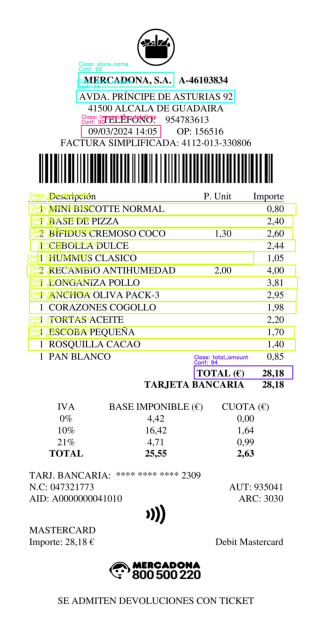

In [15]:
receipt_image_copy = receipt_image.copy()
classes_mapper = {0: "item_description", 1: "store_address", 2: "store_name", 3: "total_amount", 4: "transaction_datetime"}


if "boxes" in result:
    for idx, (x1, y1, x2, y2, conf, lbl) in enumerate(result["boxes"]):
        # If confidence lower than 0.5, do not draw the bounding box
        if conf < 0.5:
            continue

        # Map label int with its text value
        lbl_name = classes_mapper.get(lbl)
        
        # Choose a color for the bounding box
        if lbl_name == "item_description":
            color = (0, 255, 206)
        elif lbl_name == "store_address":
            color = (255, 255, 0)
        elif lbl_name == "store_name":
            color = (199, 252, 0)
        elif lbl_name == "total_amount":
            color = (254, 0, 86)
        else:
            color = (134, 34, 255) 

        # Draw Bounding Boxes
        x1, x2 = int(x_ratio*x1), int(x_ratio*x2)
        y1, y2 = int(y_ratio*y1), int(y_ratio*y2)

        cv2.rectangle(receipt_image_copy, (x1,y1), (x2,y2), color, 4)
        cv2.putText(receipt_image_copy, f"Class: {lbl_name}", (x1,y1-40), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)
        cv2.putText(receipt_image_copy, f"Conf: {int(conf*100)}", (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)

dpi = 400
figsize = (image_width / dpi, image_height / dpi)   

plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(receipt_image_copy, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

<a id="section4"></a>
## <font color="#00586D"> 4. Pruebas invocación Lambda para obtener inferencia en SageMaker</font>
<br>

In [16]:
import base64
import boto3
import json
import io
import numpy as np

SM_ENDPOINT = "yolov8-pytorch-2024-09-07-08-39-56-003428"


def lambda_handler(event, context):
    base64_image = event["receipt_image"]
    base64_decoded_image = base64.b64decode(base64_image)

    np_array = np.frombuffer(base64_decoded_image, np.uint8)
    image_io = io.BytesIO()
    np.save(image_io, np_array, allow_pickle=True)
    payload = image_io.getvalue()

    
    runtime_sm_client = boto3.client(service_name="sagemaker-runtime", region_name="us-east-1")
    endpoint_name = SM_ENDPOINT
        
    response = runtime_sm_client.invoke_endpoint(
        EndpointName=endpoint_name,
        Body=payload,
        ContentType="application/x-npy"
        )
    
    result = json.load(response["Body"])
    
    return {
        "statusCode": 200,
        "body": json.dumps(result)
    }

In [17]:
# Invoke Lambda from local environment
lambda_client = boto3.client("lambda", region_name = "us-east-1")

response = lambda_client.invoke(
    FunctionName="sagemaker-yolov8-inference",
    InvocationType="RequestResponse",
    Payload=json.dumps({"receipt_image": base64_image})
)

In [18]:
response_payload = json.load(response["Payload"])
response_payload

{'statusCode': 200,
 'body': '{"boxes": [[201.87973022460938, 369.71392822265625, 309.88201904296875, 383.37603759765625, 0.9464800357818604, 3.0], [78.19972229003906, 119.84982299804688, 165.1860809326172, 132.57510375976562, 0.9000394344329834, 4.0], [21.40386962890625, 303.02691650390625, 313.4872741699219, 315.42767333984375, 0.890390932559967, 0.0], [23.24517822265625, 213.75146484375, 310.36126708984375, 225.5284423828125, 0.8762845396995544, 0.0], [21.547027587890625, 289.91107177734375, 314.66314697265625, 302.58209228515625, 0.8758519887924194, 0.0], [20.50946044921875, 341.8853759765625, 312.78961181640625, 353.966064453125, 0.8699733018875122, 0.0], [22.505615234375, 238.63217163085938, 312.55242919921875, 250.79861450195312, 0.8658813834190369, 0.0], [21.60516357421875, 226.41351318359375, 309.9823303222656, 238.67324829101562, 0.8645515441894531, 0.0], [21.701446533203125, 276.7589111328125, 314.98284912109375, 289.64617919921875, 0.8198563456535339, 0.0], [72.898193359375

In [19]:
# Inspect results
bboxes_payload = json.loads(response_payload["body"])
bboxes_payload

{'boxes': [[201.87973022460938,
   369.71392822265625,
   309.88201904296875,
   383.37603759765625,
   0.9464800357818604,
   3.0],
  [78.19972229003906,
   119.84982299804688,
   165.1860809326172,
   132.57510375976562,
   0.9000394344329834,
   4.0],
  [21.40386962890625,
   303.02691650390625,
   313.4872741699219,
   315.42767333984375,
   0.890390932559967,
   0.0],
  [23.24517822265625,
   213.75146484375,
   310.36126708984375,
   225.5284423828125,
   0.8762845396995544,
   0.0],
  [21.547027587890625,
   289.91107177734375,
   314.66314697265625,
   302.58209228515625,
   0.8758519887924194,
   0.0],
  [20.50946044921875,
   341.8853759765625,
   312.78961181640625,
   353.966064453125,
   0.8699733018875122,
   0.0],
  [22.505615234375,
   238.63217163085938,
   312.55242919921875,
   250.79861450195312,
   0.8658813834190369,
   0.0],
  [21.60516357421875,
   226.41351318359375,
   309.9823303222656,
   238.67324829101562,
   0.8645515441894531,
   0.0],
  [21.701446533203